# 06 — Post-IPO review: predicted vs realized

> **The pre-registration is frozen.** This notebook is an *added* layer: it does not modify
> `PREDICTIONS.md`, the evaluation metrics, or the baseline notebooks/charts (01–05). It reads the
> **frozen** day-1 checkpoint + pre-debut Polymarket odds and holds them against **live, realized**
> data. Everything dated before 2026-06-12 is the contract; everything here is the scoring.

What it answers, two weeks after the debut (T+9 sessions):
1. How did the day-1 bet resolve? (P1/P2)
2. Were the probabilities — ours and the market's — calibrated?
3. The IV reality check the README promised: did the model's assumed vol meet the listed-option IV?
4. Where did the realized path land inside the Monte Carlo cone?

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.viz import tufte_style, headline, PALETTE, GOOD, BAD, NEUTRAL
tufte_style()
SHARES = 6_824_641_355 + 555_555_555 + 5_695_668_265  # 424B4 dual-class total
CKPT = Path.cwd().parent / "checkpoints" 

## 1. The debut outcome (frozen day-1 close)

Scored on the **immutable** 2026-06-12 bar, not a later rolling close (see PR #6).

In [2]:
import tools.score as sc
name, snap, close_d1 = sc.day1_snapshot(CKPT)
ipo_price = 135.0
cap_d1 = close_d1 * SHARES
pop = close_d1 / ipo_price - 1
debut = pd.DataFrame([
    {"metric": "IPO price", "value": f"${ipo_price:,.0f}"},
    {"metric": "Day-1 close (frozen)", "value": f"${close_d1:,.2f}  [{name}]"},
    {"metric": "Day-1 pop", "value": f"{pop:+.1%}"},
    {"metric": "Day-1 market cap (424B4)", "value": f"${cap_d1/1e12:.3f}T"},
    {"metric": "P1  cap > $1T  (ex-ante 0.97)", "value": "TRUE" if cap_d1 > 1e12 else "FALSE"},
    {"metric": "P2  cap > $2T  (ex-ante 0.60)", "value": "TRUE" if cap_d1 > 2e12 else "FALSE"},
]).set_index("metric")
debut

,value
metric,
IPO price,$135
Day-1 close (frozen),$160.95 [2026-06-13-ci-verify]
Day-1 pop,+19.2%
Day-1 market cap (424B4),$2.105T
P1 cap > $1T (ex-ante 0.97),TRUE
P2 cap > $2T (ex-ante 0.60),TRUE


## 2. Calibration — the market's odds and ours vs what happened

Pre-debut Polymarket prices are pulled from the **frozen** baseline checkpoint (2026-06-10). Both the crowd and our pre-registered P landed on the right side of the $2T line — and near its probability.

In [3]:
pm = json.load(open(CKPT / "2026-06-10-baseline" / "polymarket.json"))
def yes(substr):
    for m in pm:
        if substr.lower() in m["market"].lower() and m["outcomes"].get("Yes") is not None:
            return m["outcomes"]["Yes"]
    return None
realized_above = lambda thr: "TRUE" if cap_d1 > thr else "FALSE"
cal = pd.DataFrame([
    {"question": "cap > $1T", "Polymarket P(Yes) pre-debut": yes("above $1T"),
     "our ex-ante P": 0.97, "realized": realized_above(1e12)},
    {"question": "cap > $2T", "Polymarket P(Yes) pre-debut": yes("above $2T"),
     "our ex-ante P": 0.60, "realized": realized_above(2e12)},
]).set_index("question")
cal

,Polymarket P(Yes) pre-debut,our ex-ante P,realized
question,,,
cap > $1T,0.9895,0.97,TRUE
cap > $2T,0.6250,0.60,TRUE


## 3. The IV reality check (README promised: *the model's guessed IV meets reality*)

The baseline Monte Carlo assumed `spcx_vol` as a pre-listing placeholder. Now that SPCX options are real (`identity_suspect` cleared), the listed ATM implied vol for the **August unlock** expiry is the market's answer.

In [4]:
from src.risk.montecarlo import McConfig
assumed_vol = McConfig().spcx_vol
real_iv, iv_exp, spot = None, None, None
try:
    import yfinance as yf
    t = yf.Ticker("SPCX"); exps = t.options or []
    spot = float(t.history(period="1d")["Close"].iloc[-1])
    aug = next((e for e in exps if e.startswith("2026-08")), exps[1] if len(exps) > 1 else (exps[0] if exps else None))
    if aug:
        oc = t.option_chain(aug); calls = oc.calls.copy()
        calls["d"] = (calls["strike"] - spot).abs()
        real_iv = float(calls.nsmallest(3, "d")["impliedVolatility"].mean()); iv_exp = aug
except Exception as e:
    print("live IV unavailable:", str(e)[:80])
print(f"MC assumed spcx_vol : {assumed_vol:.0%}")
if real_iv:
    print(f"Listed ATM IV ({iv_exp}): {real_iv:.0%}  (spot ${spot:.0f})")
    print(f"-> the baseline understated vol by {real_iv-assumed_vol:+.0%}. Realized regime is "
          f"fatter than the placeholder; a put spread is priced richer than the model assumed.")

MC assumed spcx_vol : 70%
Listed ATM IV (2026-08-07): 91%  (spot $134)
-> the baseline understated vol by +21%. Realized regime is fatter than the placeholder; a put spread is priced richer than the model assumed.


## 4. Realized path vs the Monte Carlo cone

Baseline MC (Student-t dof=4, the frozen config) re-anchored to the **actual** day-1 close $160.95 — not the old $150 placeholder. The realized closes are overlaid. The question is not whether the median was right (it never is) but whether reality stayed inside the cone.

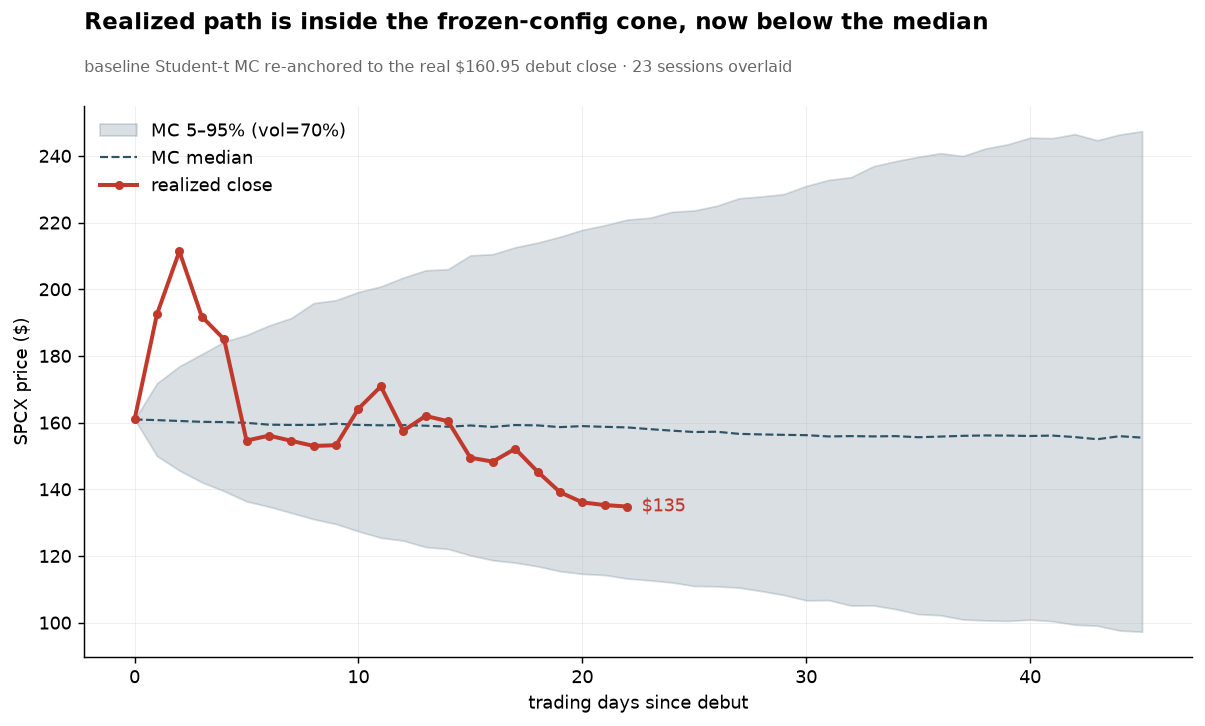

In [5]:
# Committed evidence, same series every post-IPO visual reads (bug 19: a live fetch here
# let this chart, the gif and chart_mc_vs_realized drift apart within the same README).
from tools.evidence import latest_checkpoint, realized_closes
realized = realized_closes(latest_checkpoint(CKPT))
rx = np.arange(len(realized))

cfg = McConfig()
rng = np.random.default_rng(cfg.seed)
# Horizon grows with the realized series so the cone never runs out (was a fixed 45,
# which would IndexError once the tape passed it, ~mid-Aug).
n, days, dt = 3000, max(45, len(realized) + 10), 1 / 252
scale = np.sqrt(cfg.t_dof / (cfg.t_dof - 2))
z = rng.standard_t(cfg.t_dof, size=(n, days)) / scale
logret = (cfg.spcx_drift - 0.5 * cfg.spcx_vol**2) * dt + cfg.spcx_vol * np.sqrt(dt) * z
paths = close_d1 * np.exp(np.cumsum(logret, axis=1))
paths = np.column_stack([np.full(n, close_d1), paths])
p5, p50, p95 = np.percentile(paths, [5, 50, 95], axis=0)
x = np.arange(days + 1)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.fill_between(x, p5, p95, color=PALETTE[0], alpha=0.18, label="MC 5–95% (vol=70%)")
ax.plot(x, p50, color=PALETTE[0], lw=1.2, ls="--", label="MC median")
ax.plot(rx, realized, color=BAD, lw=2.2, marker="o", ms=4, label="realized close")
ax.annotate(f"${realized[-1]:.0f}", (rx[-1], realized[-1]),
            xytext=(8, 0), textcoords="offset points", va="center", color=BAD, fontsize=10)
last = len(realized) - 1
inside = (realized[-1] >= p5[last]) and (realized[-1] <= p95[last])
side = "above" if realized[-1] >= p50[last] else "below"
headline(ax, f"Realized path is {'inside' if inside else 'OUTSIDE'} the frozen-config cone, now {side} the median",
         f"baseline Student-t MC re-anchored to the real $160.95 debut close · {len(realized)} sessions overlaid")
ax.set_xlabel("trading days since debut"); ax.set_ylabel("SPCX price ($)")
ax.legend(loc="upper left")
fig.savefig("../assets/chart_post_ipo.png", bbox_inches="tight")
plt.show()

## 5. Verdict so far (2026-06-25, T+9)

- **Day-1 bet resolved correctly**: +19.2% pop, $2.105T cap → **P1 and P2 both TRUE**, scored on the frozen close (the scoring-drift bug that would have un-resolved this is fixed, PR #6).
- **Calibration held**: Polymarket priced cap>$2T at ~0.63 and our pre-registered P2 was 0.60 — both on the right side, both near the realized truth. No overconfidence to flag yet.
- **The model under-vol'd**: assumed 70% vs listed ATM IV ~88% for the August expiry. The put spread the plan buys in July is therefore *more expensive* than the baseline implied — judge the entry on real IV, exactly as the sensitivity note warned. The two-week round-trip below is the realized version of that under-priced vol.
- **The pop round-tripped**: the realized path spiked to ~$211 on session 3 — briefly *above* the frozen 95th-percentile band — then unwound through the median to **$153** by T+9, just below the $160.95 debut close. Still inside the cone, but now in its lower half, not the upper band it was hugging six sessions in. The day-1 fact is frozen and unaffected; the post-debut tape is simply doing what 88% IV said it would.

**Still ahead and untouched**: the July spread entry, the August earnings + insider unlock (the whole thesis), and `form4_watch()` going live. The pre-registration stands; this page only keeps score.